<a href="https://colab.research.google.com/github/Rakmik/NM/blob/main/%D0%9B%D0%A0%E2%84%9613_%D0%97%D0%B0%D0%B3%D0%B8%D0%BD%D0%B0%D0%B9%D0%BA%D0%BE_%D0%9F%D0%B0%D0%B2%D0%BB%D0%BE_%D0%A4%D0%86%D0%A2_2_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Загинайко Павло ФІТ 2-17

#Варіант 8

Був присутній на парі

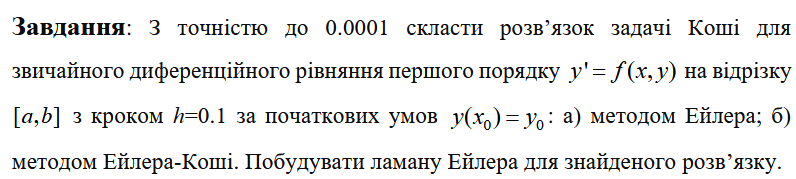

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Методом Ейлера

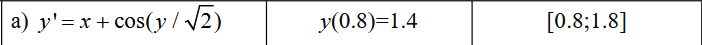

x = [0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8]
y = [1.4    1.5349 1.6715 1.8094 1.9482 2.0874 2.2268 2.3665 2.5062 2.6462
 2.7866]


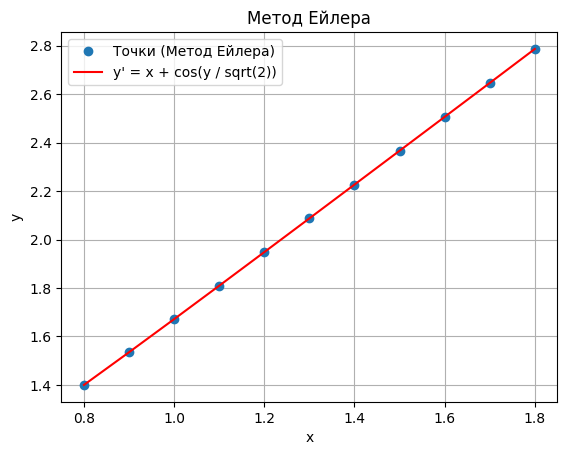

In [18]:
# Визначаємо функцію
def f(x, y):
    return x + np.cos(y / np.sqrt(2))

# Параметри
a = 0.8       # ліва межа
b = 1.8       # права межа
h = 0.1       # крок
y0 = 1.4

# Перевірка вхідних параметрів
if h <= 0:
    print("Крок h повинен бути позитивним.")
    exit()
if a >= b:
    print("Права межа b повинна бути більшою за ліву межу a.")
    exit()

n = int((b - a) / h)  # кількість кроків
x = np.array([a + i*h for i in range(n + 1)])
y = np.empty(n + 1)
y[0] = y0

# Метод Ейлера
for i in range(n):
    y[i + 1] = y[i] + f(x[i], y[i]) * h

# Вивід результатів
y_rounded = np.round(y, 4)
print("x =", np.round(x, 2))
print("y =", y_rounded)

# Візуалізація
plt.plot(x, y, "o", label="Точки (Метод Ейлера)")
plt.plot(x, y, "red", label="y' = x + cos(y / sqrt(2))")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Метод Ейлера")
plt.legend()
plt.grid()
plt.show()

Методом Ейлера-Коші

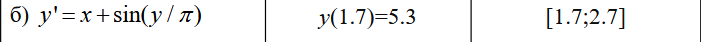

x = [1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7]
y = [5.3    5.5736 5.8555 6.1447 6.4405 6.7418 7.0479 7.3579 7.6709 7.9864
 8.3035]


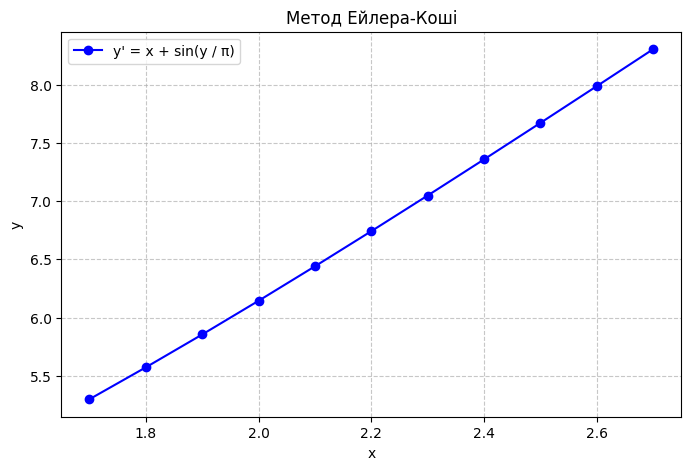

In [16]:
def f(x, y):
    return x + np.sin(y / np.pi)

# Параметри
a = 1.7        # ліва межа відрізку
b = 2.7        # права межа відрізку
y0 = 5.3       # початкова умова
h = 0.1        # крок

n = int((b - a) / h)

x = np.linspace(a, b, n + 1)
y = np.zeros(n + 1)
y[0] = y0

# Метод Ейлера-Коші
for i in range(n):
    k1 = f(x[i], y[i])
    y_predict = y[i] + h * k1
    k2 = f(x[i+1], y_predict)
    y[i + 1] = y[i] + (h / 2) * (k1 + k2)

# Округлення для виводу
y_rounded = np.round(y, 4)
x_rounded = np.round(x, 2)

print(f"x = {x_rounded}")
print(f"y = {y_rounded}")

# Візуалізація
plt.figure(figsize=(8, 5))
plt.plot(x, y, "bo-", label="y' = x + sin(y / π)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Метод Ейлера-Коші")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Точки x: [1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7]
Точне y: [5.3    5.5737 5.8556 6.145  6.4407 6.7421 7.0482 7.3581 7.6712 7.9867
 8.3039]


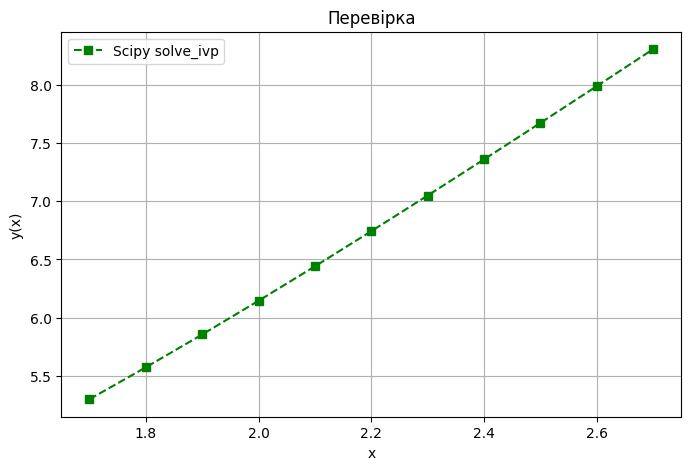

In [17]:
def model(x, y):
    return x + np.sin(y / np.pi)

y0 = [5.3]
x_start = 1.7
x_end = 2.7

x_eval = np.linspace(x_start, x_end, 11)

sol = solve_ivp(model, [x_start, x_end], y0, t_eval=x_eval)

print('Точки x:', np.round(sol.t, 2))
print('Точне y:', np.round(sol.y[0], 4))

plt.figure(figsize=(8, 5))
plt.plot(sol.t, sol.y[0], color='green', marker='s', linestyle='--', label='Scipy solve_ivp')
plt.xlabel('x')
plt.ylabel('y(x)')
plt.title('Перевірка')
plt.legend()
plt.grid(True)
plt.show()